# Supervised Learning - Stage 2

Stage 2 covers:
- Loading all three classification tasks from Stage 1
- Applying the appropriate imbalance strategy per task (determined in Stage 1)
- Persisting three self-contained pkl files for downstream model stages

| Task | Strategy (from Stage 1) |
|------|------------------------|
| multiclass | SMOTE + class_weight |
| binary | determined at runtime |
| categorical | determined at runtime |

**Design principle:** SMOTE is only ever applied to the training set. The test set is
never touched - it must reflect the real-world class distribution to produce honest
evaluation metrics.

---
# 1. Configuration and Imports

In [7]:
import os
import pickle
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')


def find_project_root(marker='config.yml'):
    current = Path().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Could not find {marker} in any parent directory')


ROOT_DIR = find_project_root()
NOTEBOOKS_DIR = ROOT_DIR / 'notebooks'

with open(ROOT_DIR / 'config.yml') as f:
    cfg = yaml.safe_load(f)

with open(NOTEBOOKS_DIR / 'notebook-config.yml') as f:
    nb_cfg = yaml.safe_load(f)

NB_CONFIG = {
    'figsize_wide': nb_cfg['plotting']['figsize_wide'],
    'palette':      nb_cfg['plotting']['palette'],
}

sns.set_theme(style='whitegrid', palette=NB_CONFIG['palette'])
print(f'Project root: {ROOT_DIR}')
print('Configs loaded.')

Project root: /home/zayeer/Projects/Sheffield-Road-Collision-Detection-Coursework
Configs loaded.


---
# 2. Load Stage 1 Outputs

In [8]:
with open(NOTEBOOKS_DIR / 'stage_outputs' / 'stage1.pkl', 'rb') as f:
    stage1 = pickle.load(f)

for task_name, data in stage1.items():
    print(f'[{task_name}]')
    print(f'  X_train: {data["X_train"].shape}  |  X_test: {data["X_test"].shape}')
    print(f'  Train class distribution: {dict(sorted(Counter(data["y_train"]).items()))}')
    print(f'  Imbalance ratio: {data["imbalance_ratio"]:.1f}:1')
    print(f'  Strategy: {data["smote_strategy"]}')
    print()

[multiclass]
  X_train: (5806, 26)  |  X_test: (1452, 26)
  Train class distribution: {1: 74, 2: 896, 3: 4836}
  Imbalance ratio: 65.7:1
  Strategy: SMOTE + class_weight

[binary]
  X_train: (5806, 5)  |  X_test: (1452, 5)
  Train class distribution: {0: 5526, 1: 280}
  Imbalance ratio: 19.7:1
  Strategy: SMOTE + class_weight

[categorical]
  X_train: (5806, 6)  |  X_test: (1452, 6)
  Train class distribution: {0: 2277, 13: 2165, 16: 809, 17: 169, 18: 137, 19: 249}
  Imbalance ratio: 16.5:1
  Strategy: SMOTE + class_weight



---
# 3. Imbalance Strategy Reference

| Strategy | When applied | Rationale |
|----------|--------------|-----------|
| `SMOTE + class_weight` | ratio >= 10:1 AND all classes have >= 6 samples | SMOTE generates synthetic minority samples by interpolating between neighbours. Combined with `class_weight='balanced'` in the model for maximum effect. |
| `class_weight only` | ratio < 10:1, OR any class has < 6 samples | Either the imbalance is mild enough that reweighting suffices, or SMOTE cannot safely operate (requires k_neighbors=5, so needs at least 6 samples per class). |

The strategy for each task was determined empirically in Stage 1 and is read directly
from the persisted `smote_strategy` field - this notebook does not re-derive it.

---
# 4. Apply Imbalance Strategy Per Task

In [9]:
def apply_imbalance_strategy(task_name, X_train, y_train, strategy, smote_random_state):
    """
    Apply the appropriate imbalance strategy to the training set.

    Returns (X_resampled, y_resampled, was_smoted: bool).
    If strategy does not include SMOTE, returns the original arrays unchanged.
    """
    if 'SMOTE' in strategy:
        smote = SMOTE(
            random_state=smote_random_state,
            k_neighbors=5,
        )
        X_res, y_res = smote.fit_resample(X_train, y_train) # type: ignore
        return X_res, y_res, True
    else:
        # class_weight only - training data is unchanged
        # class_weight='balanced' must be set in each model that supports it
        return X_train.copy(), y_train.copy(), False


stage2_outputs = {}

for task_name, data in stage1.items():
    X_train = data['X_train']
    y_train = data['y_train']
    strategy = data['smote_strategy']

    X_res, y_res, was_smoted = apply_imbalance_strategy(
        task_name, X_train, y_train,
        strategy,
        cfg['supervised']['smote_random_state'],
    )

    stage2_outputs[task_name] = {
        'X_train': X_res,
        'y_train': y_res,
        'X_test':  data['X_test'],
        'y_test':  data['y_test'],
        'smote_applied': was_smoted,
        'smote_strategy': strategy,
    }

    before = Counter(y_train)
    after  = Counter(y_res)

    print(f'[{task_name}] strategy: {strategy}')
    print(f'  Samples before: {len(y_train):,}  ->  after: {len(y_res):,}')
    if was_smoted:
        print(f'  Synthetic samples added: {len(y_res) - len(y_train):,}')
    print(f'  Class distribution after: {dict(sorted(after.items()))}')
    print()

[multiclass] strategy: SMOTE + class_weight
  Samples before: 5,806  ->  after: 14,508
  Synthetic samples added: 8,702
  Class distribution after: {1: 4836, 2: 4836, 3: 4836}

[binary] strategy: SMOTE + class_weight
  Samples before: 5,806  ->  after: 11,052
  Synthetic samples added: 5,246
  Class distribution after: {0: 5526, 1: 5526}

[categorical] strategy: SMOTE + class_weight
  Samples before: 5,806  ->  after: 13,662
  Synthetic samples added: 7,856
  Class distribution after: {0: 2277, 13: 2277, 16: 2277, 17: 2277, 18: 2277, 19: 2277}



---
# 5. Visualize Before / After Per Task

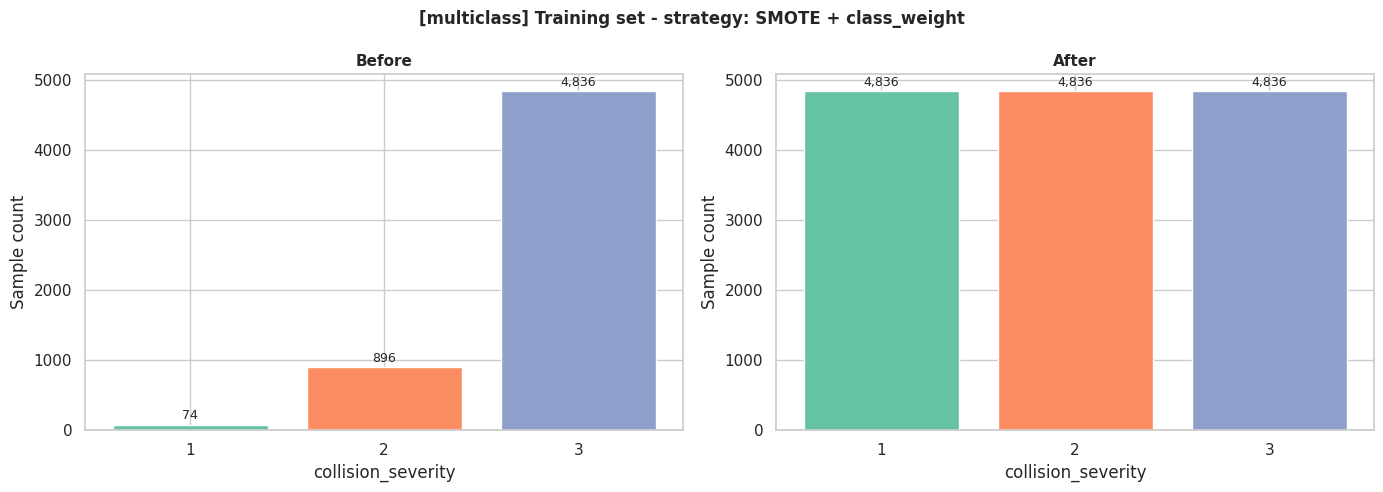

  Test set distribution (unchanged): {1: 18, 2: 224, 3: 1210}



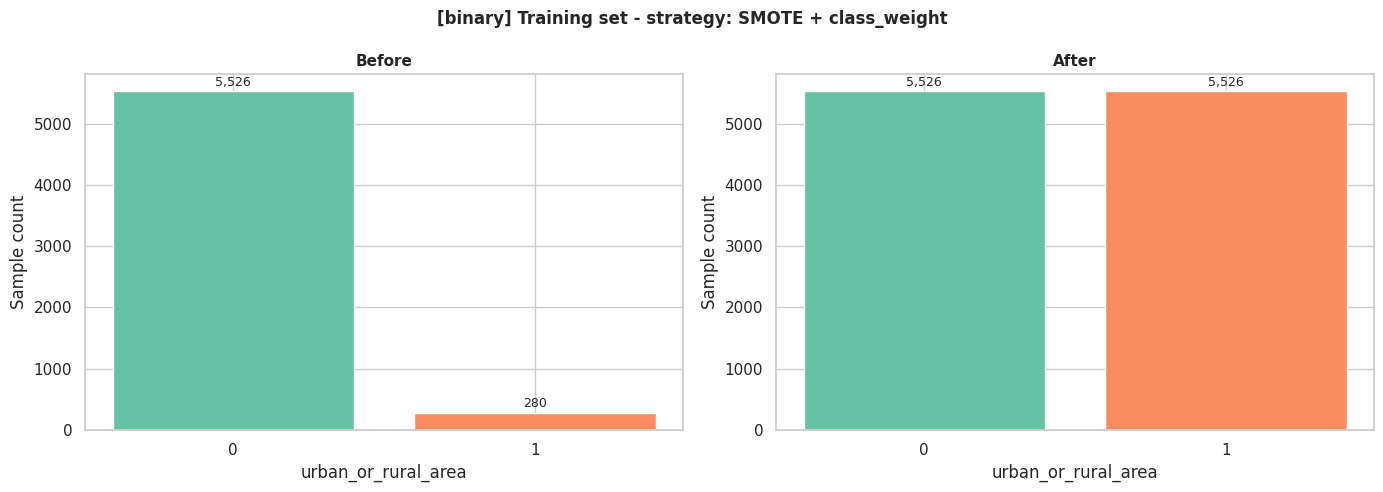

  Test set distribution (unchanged): {0: 1382, 1: 70}



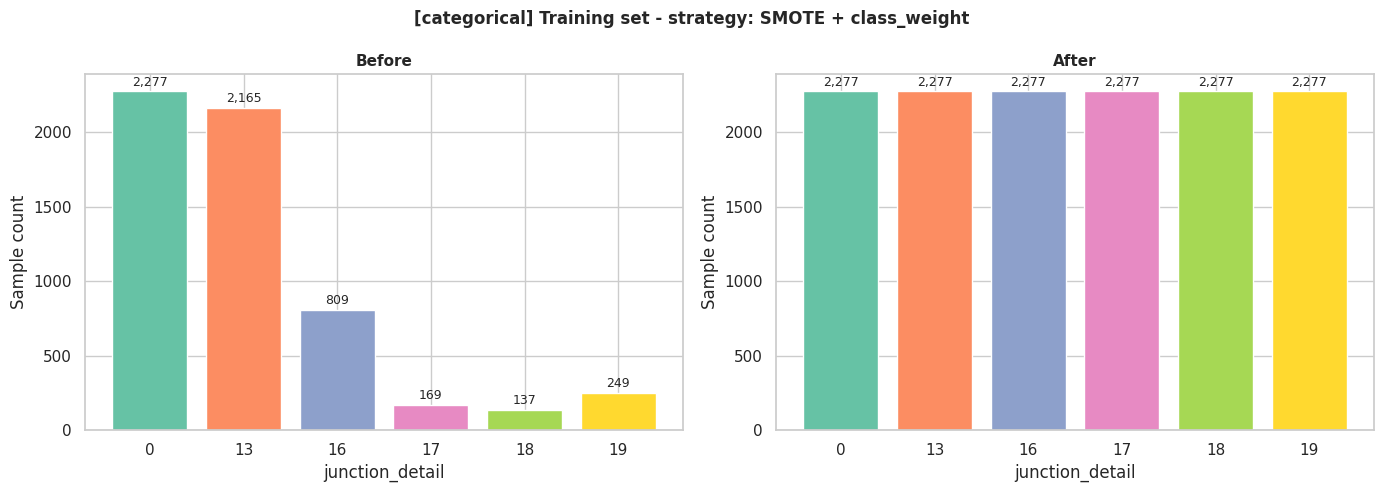

  Test set distribution (unchanged): {0: 569, 13: 541, 16: 203, 17: 42, 18: 35, 19: 62}



In [10]:
tasks_cfg = cfg['supervised']['tasks']
colors = sns.color_palette(NB_CONFIG['palette'])

for task_name, data in stage1.items():
    out = stage2_outputs[task_name]
    before = Counter(data['y_train'])
    after  = Counter(out['y_train'])
    classes = sorted(before.keys())

    fig, axes = plt.subplots(1, 2, figsize=tuple(NB_CONFIG['figsize_wide']))
    task_colors = colors[:len(classes)]

    for ax, (dist, title) in zip(axes, [
        (before, 'Before'),
        (after,  'After'),
    ], strict=False):
        counts = [dist[c] for c in classes]
        bars = ax.bar([str(c) for c in classes], counts,
                      color=task_colors, edgecolor='white')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel(tasks_cfg[task_name]['target_col'])
        ax.set_ylabel('Sample count')
        for bar, count in zip(bars, counts, strict=False):
            ax.annotate(
                f'{count:,}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=9
            )

    strategy_label = out['smote_strategy']
    fig.suptitle(
        f'[{task_name}] Training set - strategy: {strategy_label}',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    # Confirm test set is untouched
    test_dist = Counter(out['y_test'])
    print(f'  Test set distribution (unchanged): {dict(sorted(test_dist.items()))}')
    print()

---
# 6. Stage 2 Summary

In [11]:
import pandas as pd

summary_rows = []
for task_name, out in stage2_outputs.items():
    before_counts = Counter(stage1[task_name]['y_train'])
    after_counts  = Counter(out['y_train'])
    summary_rows.append({
        'Task':             task_name,
        'SMOTE applied':    out['smote_applied'],
        'Train before':     sum(before_counts.values()),
        'Train after':      sum(after_counts.values()),
        'Synthetic added':  sum(after_counts.values()) - sum(before_counts.values()),
        'Test samples':     len(out['y_test']),
        'Strategy':         out['smote_strategy'],
    })

summary_df = pd.DataFrame(summary_rows).set_index('Task')
print('Stage 2 Summary:')
summary_df

Stage 2 Summary:


,SMOTE applied,Train before,Train after,Synthetic added,Test samples,Strategy
Task,,,,,,
multiclass,True,5806,14508,8702,1452,SMOTE + class_weight
binary,True,5806,11052,5246,1452,SMOTE + class_weight
categorical,True,5806,13662,7856,1452,SMOTE + class_weight


---
# 7. Persist Stage 2 Outputs

One pkl file per task. Each file is self-contained:
- `X_train` / `y_train`: resampled training data (or original if SMOTE not applied)
- `X_test` / `y_test`: original, untouched test data
- `smote_applied`: bool flag so downstream stages know whether to also set `class_weight='balanced'`
- `smote_strategy`: full strategy string for reporting

In [12]:
output_dir = NOTEBOOKS_DIR / 'stage_outputs'
os.makedirs(output_dir, exist_ok=True)

for task_name, out in stage2_outputs.items():
    output_path = output_dir / f'stage2-{task_name}.pkl'
    with open(output_path, 'wb') as f:
        pickle.dump(out, f)
    print(f'Saved: {output_path}')

print()
print('Downstream stages load via:')
for task_name in stage2_outputs:
    print(f'  stage2-{task_name}.pkl  ->  X_train, y_train, X_test, y_test, smote_applied, smote_strategy')

Saved: /home/zayeer/Projects/Sheffield-Road-Collision-Detection-Coursework/notebooks/stage_outputs/stage2-multiclass.pkl
Saved: /home/zayeer/Projects/Sheffield-Road-Collision-Detection-Coursework/notebooks/stage_outputs/stage2-binary.pkl
Saved: /home/zayeer/Projects/Sheffield-Road-Collision-Detection-Coursework/notebooks/stage_outputs/stage2-categorical.pkl

Downstream stages load via:
  stage2-multiclass.pkl  ->  X_train, y_train, X_test, y_test, smote_applied, smote_strategy
  stage2-binary.pkl  ->  X_train, y_train, X_test, y_test, smote_applied, smote_strategy
  stage2-categorical.pkl  ->  X_train, y_train, X_test, y_test, smote_applied, smote_strategy
